# PRo Posterior Variational Inference ($k=2$ MMD)

This notebook demonstrates the derivation of a Predictively Oriented (PRo) posterior using a tractable predictive scoring rule.

## 1. Mathematical Objective
The algorithm seeks to minimise the following objective function to find the optimal distribution $Q_n$:
$$Q_n = \text{argmin}_{Q} \left\{ \frac{\lambda_n}{n} \sum_{i=1}^n \widehat{S}\left(\int P_\theta \text{d}Q(\theta), x_i\right) + \text{KL}(Q||\Pi) \right\}$$

## 2. Tractable Approximation (Equation 3)
Because integrating the continuous ensemble is intractable, we approximate the score $\widehat{S}$ using the squared MMD loss, which requires $k=2$ independent samples from $Q$:
$$\widehat{S} \approx \int L(\theta_{1:2}, x_i)\text{d}Q^2(\theta_{1:2})$$

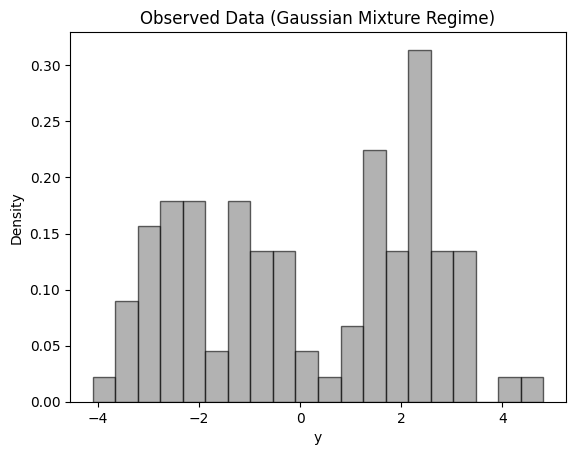

In [21]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup and Data Generation
torch.manual_seed(42)
# Simulating bimodal observed data x (misspecified regime)
data = torch.cat([torch.randn(50) - 2.0, torch.randn(50) + 2.0])
n = len(data)

# Visualise the raw data
plt.hist(data.numpy(), bins=20, density=True, alpha=0.6, color='grey', edgecolor='black')
plt.title("Observed Data (Gaussian Mixture Regime)")
plt.xlabel("y")
plt.ylabel("Density")
plt.show()

In [22]:
# 2. Define the Substitute Loss Function L (MMD with k=2)
def rbf_kernel(x, y, bandwidth=1.0):
    """Calculates the Gaussian radial basis function kernel."""
    return torch.exp(-0.5 * ((x - y) / bandwidth) ** 2)

def compute_mmd_loss(theta1, theta2, x_i):
    """Computes empirical MMD between true data x_i and synthetic predictions."""
    # Generate synthetic predictions y from the base model P_theta
    y1 = theta1 + torch.randn_like(theta1) 
    y2 = theta2 + torch.randn_like(theta2)
    
    # Calculate kernel interactions
    k_y1_y2 = rbf_kernel(y1, y2)
    k_y1_x = rbf_kernel(y1, x_i)
    k_y2_x = rbf_kernel(y2, x_i)
    k_x_x = rbf_kernel(x_i, x_i) 
    
    # Calculate the diversity and accuracy penalty
    return k_y1_y2 - k_y1_x - k_y2_x + k_x_x

In [23]:
from tqdm.notebook import tqdm

In [54]:
# 3. Optimisation Setup
mu = torch.tensor([0.0], requires_grad=True)
log_sigma = torch.tensor([0.0], requires_grad=True) 

prior_mu = 0.0
prior_sigma = 10.0

optimizer = optim.Adam([mu, log_sigma], lr=0.001)
epochs = 300
lambda_n = 500


mmd_losses = []
kl_div_losses = []

# Optimisation Loop
for epoch in tqdm(range(epochs)):
    optimizer.zero_grad()
    sigma = torch.exp(log_sigma)
    
    # Draw strictly two independent samples from Q
    theta1 = mu + sigma * torch.randn(1)
    theta2 = mu + sigma * torch.randn(1)
    
    # Sum the loss over all observed data points
    mmd_sum = 0
    for x_i in data:
        mmd_sum += compute_mmd_loss(theta1, theta2, x_i)
        
    avg_mmd_loss = (lambda_n / n) * mmd_sum
    
    # Calculate KL Divergence penalty
    kl_div = torch.log(torch.tensor(prior_sigma) / sigma) + (sigma**2 + (mu - prior_mu)**2) / (2 * prior_sigma**2) - 0.5
    
    # Minimise the master objective function
    loss = avg_mmd_loss + kl_div
    mmd_losses.append(avg_mmd_loss)
    kl_div_losses.append(kl_div)
    loss.backward()
    optimizer.step()

print(f"Optimised Q Mean: {mu.item():.4f}")
print(f"Optimised Q Std Dev: {torch.exp(log_sigma).item():.4f}")

  0%|          | 0/300 [00:00<?, ?it/s]

Optimised Q Mean: 0.0977
Optimised Q Std Dev: 1.2710


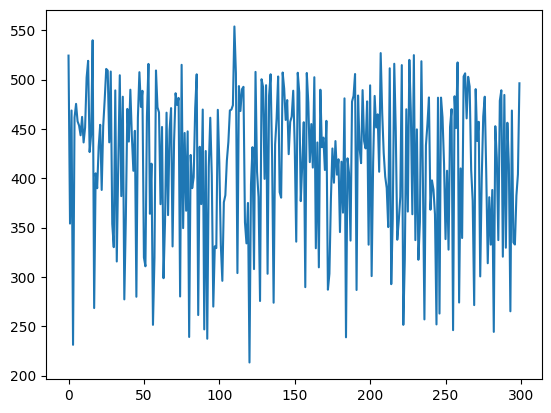

In [57]:
plt.plot(range(len(mmd_losses)), [float(l) for l in mmd_losses])
# plt.plot(range(len(kl_div_losses)), [float(l) for l in kl_div_losses])

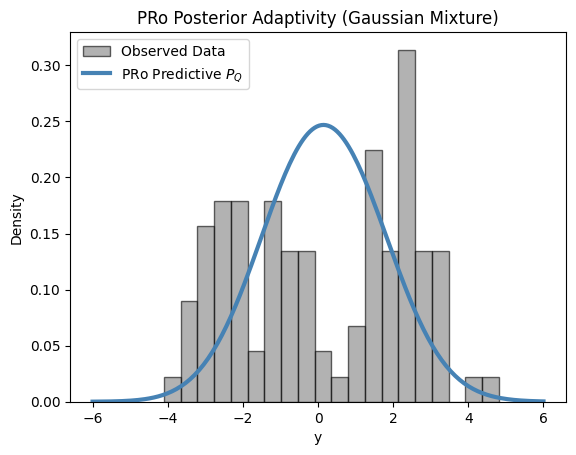

In [56]:
# 4. Visualise the Final Predictive Distribution
y_grid = torch.linspace(-6, 6, 200)
sigma_opt = torch.exp(log_sigma).detach()
mu_opt = mu.detach()

# Sample from the optimised posterior Q_n to build the ensemble
num_samples = 1000
theta_samples = mu_opt + sigma_opt * torch.randn(num_samples)

# Calculate the predictive density (averaging base models P_theta)
predictive_density = torch.zeros_like(y_grid)
for theta in theta_samples:
    # PDF of base model N(theta, sigma^2=1)
    pdf = torch.exp(-0.5 * (y_grid - theta)**2) / np.sqrt(2 * np.pi)
    predictive_density += pdf
    
predictive_density /= num_samples

# Plotting
plt.hist(data.numpy(), bins=20, density=True, alpha=0.6, color='grey', edgecolor='black', label='Observed Data')
plt.plot(y_grid.numpy(), predictive_density.numpy(), color='steelblue', linewidth=3, label='PRo Predictive $P_Q$')
plt.title("PRo Posterior Adaptivity (Gaussian Mixture)")
plt.xlabel("y")
plt.ylabel("Density")
plt.legend()
plt.show()

# try 2

In [60]:
# 1. Flexible Empirical Distribution Setup
num_particles = 100
# Initialise particles randomly spread out
theta_particles = torch.randn(num_particles, requires_grad=True) 

# Lower learning rate slightly for particle stability
optimizer = optim.Adam([theta_particles], lr=0.05)
epochs = 200
lambda_n = 500.0
prior_sigma = 10.0

# 2. Stabilised Optimisation Loop
for epoch in tqdm(range(epochs)):
    optimizer.zero_grad()
    
    epoch_loss = 0
    num_mc_draws = 15 # Average over 15 pairs to smooth the erratic loss
    
    for _ in range(num_mc_draws):
        # Draw strictly two independent samples by picking random particles
        indices = torch.randint(0, num_particles, (2,))
        theta1 = theta_particles[indices[0]]
        theta2 = theta_particles[indices[1]]
        
        # Sum the loss over all observed data points
        mmd_sum = 0
        for x_i in data:
            mmd_sum += compute_mmd_loss(theta1, theta2, x_i)
            
        epoch_loss += mmd_sum
        
    avg_mmd_loss = (lambda_n / n) * (epoch_loss / num_mc_draws)
    
    # Simplified KL Divergence regularisation for empirical particles
    kl_div = torch.mean(theta_particles**2) / (2 * prior_sigma**2)
    
    # Minimise the master objective function
    loss = avg_mmd_loss + kl_div
    loss.backward()
    optimizer.step()

  0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

  0%|          | 0/800 [00:00<?, ?it/s]

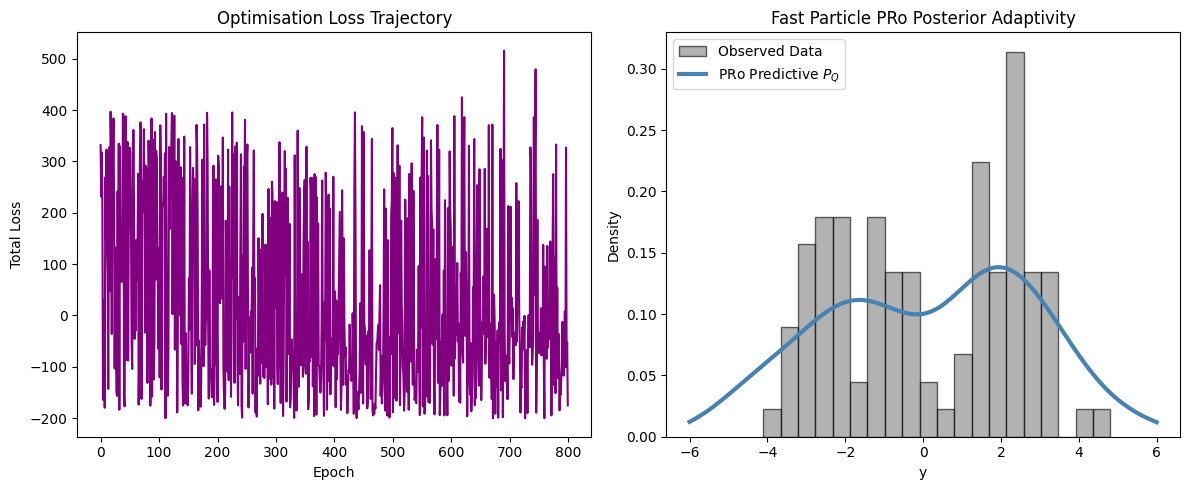

In [70]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup and Data
torch.manual_seed(42)
data = torch.cat([torch.randn(50) - 2.0, torch.randn(50) + 2.0])

# 2. Fast, Vectorised MMD Loss Function
def rbf_kernel(x, y, bandwidth=1.0):
    return torch.exp(-0.5 * ((x - y) / bandwidth) ** 2)

def compute_fast_mmd(theta1, theta2, data):
    y1 = theta1 + torch.randn_like(theta1) 
    y2 = theta2 + torch.randn_like(theta2)
    
    k_y1_y2 = rbf_kernel(y1, y2)
    k_y1_x = rbf_kernel(y1, data).mean() 
    k_y2_x = rbf_kernel(y2, data).mean()
    
    k_x_x = rbf_kernel(data.unsqueeze(0), data.unsqueeze(1)).mean() 
    
    return k_y1_y2 - k_y1_x - k_y2_x + k_x_x

# 3. Fast Particle Optimisation with Loss Tracking
num_particles = 100
theta_particles = torch.randn(num_particles, requires_grad=True) 

optimizer = optim.Adam([theta_particles], lr=0.1)
epochs = 800
lambda_n = 500.0
prior_sigma = 10.0

loss_history = [] # Initialise tracking list

for epoch in tqdm(range(epochs)):
    optimizer.zero_grad()
    
    indices = torch.randint(0, num_particles, (2,))
    theta1 = theta_particles[indices[0]]
    theta2 = theta_particles[indices[1]]
    
    avg_mmd_loss = lambda_n * compute_fast_mmd(theta1, theta2, data)
    kl_div = torch.mean(theta_particles**2) / (2 * prior_sigma**2)
    
    loss = avg_mmd_loss + kl_div
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item()) # Append scalar loss

# 4. Extracting and Visualising
y_grid = torch.linspace(-6, 6, 200)
predictive_density = torch.zeros_like(y_grid)
final_particles = theta_particles.detach()

for theta in final_particles:
    pdf = torch.exp(-0.5 * (y_grid - theta)**2) / np.sqrt(2 * np.pi)
    predictive_density += pdf

predictive_density /= num_particles

# Plot 1: Loss Trajectory
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='purple')
plt.title("Optimisation Loss Trajectory")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")

# Plot 2: Predictive Distribution
plt.subplot(1, 2, 2)
plt.hist(data.numpy(), bins=20, density=True, alpha=0.6, color='grey', edgecolor='black', label='Observed Data')
plt.plot(y_grid.numpy(), predictive_density.numpy(), color='steelblue', linewidth=3, label='PRo Predictive $P_Q$')
plt.title("Fast Particle PRo Posterior Adaptivity")
plt.xlabel("y")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()